# Kepler-51 System: Exploratory Analysis of $\rho_{\rm obs}$ vs $\rho_{\rm true}$

This notebook performs an exploratory analysis of the **observed stellar density** ($\rho_{\rm obs}$) inferred from the transit light curves of each planet in the Kepler-51 system, assuming **strictly circular orbits** and using the **GeoTrans** photometric model.

The key question: does $\rho_{\rm obs}$ match $\rho_{\rm true}$ (from the Exoplanet Archive)? Anomalies ($\rho_{\rm obs} \neq \rho_{\rm true}$) can be a signature of **unmodeled physics** — such as rings, oblateness, or orbital eccentricity.

**System:** Kepler-51 (KIC 11773022)  
**Planets:** b, c, d  
**Reference:** Masuda (2014), Libby-Roberts et al. (2020), Masuda et al. (2024)  
**Archive:** [NASA Exoplanet Archive](https://exoplanetarchive.ipac.caltech.edu/overview/Kepler-51)


## 1. Setup

In [45]:
import sys
sys.path.insert(0, '.')  # ensure geotrans2.py is importable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import warnings
warnings.filterwarnings('ignore')

# GeoTrans library
import geotrans2 as gt

# Convenient aliases from GeoTrans
RSUN  = gt.RSUN
MSUN  = gt.MSUN
RJUP  = gt.RJUP
MJUP  = gt.MJUP
REARTH = gt.REARTH
MEARTH = gt.MEARTH
AU    = gt.AU
DEG   = gt.DEG
HOUR  = gt.HOUR
GCONST = gt.GCONST
pi    = np.pi

print("GeoTrans loaded successfully.")
print(f"  R_Sun = {RSUN:.4e} m")
print(f"  M_Sun = {MSUN:.4e} kg")
print(f"  rho_Sun = {gt.RHOSUN:.2f} kg/m^3")

GeoTrans loaded successfully.
  R_Sun = 6.9634e+08 m
  M_Sun = 1.9885e+30 kg
  rho_Sun = 1405.98 kg/m^3


## 2. Kepler-51 System Parameters

Parameters from the **NASA Exoplanet Archive** (default flag=1, retrieved 2026-02-23).  
Reference solutions: Masuda et al. (2024) for planets b/c/d; Morton et al. (2016) for Rp/Rs and a/Rs ratios.

Planet **e** is excluded below as it has no measured transit duration or radius (non-transiting TTV candidate).

In [46]:
# -------------------------------------------------------
# STELLAR PARAMETERS (from Masuda et al. 2024 / default)
# -------------------------------------------------------
star = {
    'name'   : 'Kepler-51',
    'Mstar'  : 1.04 * MSUN,    # kg
    'Rstar'  : 0.94 * RSUN,    # m
    # Limb darkening coefficients (quadratic; Brown et al. 2001 convention)
    'c1'     : 0,            # Kepler bandpass, solar-like (approximate)
    'c2'     : 0,
}

# Derived stellar density
star['rho_true'] = star['Mstar'] / (4*pi/3 * star['Rstar']**3)  # kg/m^3

print("=== Kepler-51 Stellar Parameters ===")
print(f"  M_star = {star['Mstar']/MSUN:.3f} M_sun")
print(f"  R_star = {star['Rstar']/RSUN:.3f} R_sun")
print(f"  rho_true (computed) = {star['rho_true']:.2f} kg/m^3")

=== Kepler-51 Stellar Parameters ===
  M_star = 1.040 M_sun
  R_star = 0.940 R_sun
  rho_true (computed) = 1760.48 kg/m^3


In [47]:
# -------------------------------------------------------
# PLANETARY PARAMETERS (NASA Exoplanet Archive, 2026-02-23)
# Only planets with observed transits and measured Rp/Rs included.
# -------------------------------------------------------

# Archive values for a/Rs (pl_ratdor) and Rp/Rs (pl_ratror)
# Impact parameter (pl_imppar), orbital period (days), Rp in Earth radii

planets_data = [
    {
        'name'      : 'Kepler-51 b',
        'label'     : 'b',
        'P_days'    : 45.154,          # orbital period [days]
        'Rp_Rstar'  : 0.07414,         # pl_ratror  (Rp/Rs)
        'aRstar'    : 61.5,            # pl_ratdor  (a/Rs)
        'b_imp'     : 0.251,           # impact parameter
        'ecc'       : 0.040,           # pl_orbeccen
        'Rp_Earth'  : 7.10,            # pl_rade [R_Earth]
        'Mp_Earth'  : 2.10,            # pl_bmasse [M_Earth]
    },
    {
        'name'      : 'Kepler-51 c',
        'label'     : 'c',
        'P_days'    : 85.312,
        'Rp_Rstar'  : 0.09400,
        'aRstar'    : 94.1,
        'b_imp'     : 0.994,           # NOTE: nearly grazing!
        'ecc'       : 0.014,
        'Rp_Earth'  : 6.4,
        'Mp_Earth'  : 6.09,
    },
    {
        'name'      : 'Kepler-51 d',
        'label'     : 'd',
        'P_days'    : 130.194,
        'Rp_Rstar'  : 0.10141,
        'aRstar'    : 124.7,
        'b_imp'     : 0.250,
        'ecc'       : 0.008,
        'Rp_Earth'  : 9.70,
        'Mp_Earth'  : 7.60,
    },
]

# Build a DataFrame for easy display
df_planets = pd.DataFrame(planets_data)

# Derived columns
df_planets['P_hours']   = df_planets['P_days'] * 24.0
df_planets['Rp_SI']     = df_planets['Rp_Rstar'] * star['Rstar']     # m
df_planets['a_SI']      = df_planets['aRstar']   * star['Rstar']     # m
df_planets['Mp_SI']     = df_planets['Mp_Earth'] * MEARTH            # kg

print(df_planets[[
    'name','P_days','Rp_Rstar','aRstar','b_imp','ecc','Rp_Earth','Mp_Earth'
]].to_string(index=False))

       name   P_days  Rp_Rstar   aRstar  b_imp    ecc  Rp_Earth  Mp_Earth
Kepler-51 b  45.1540    0.0741  61.5000 0.2510 0.0400    7.1000    2.1000
Kepler-51 c  85.3120    0.0940  94.1000 0.9940 0.0140    6.4000    6.0900
Kepler-51 d 130.1940    0.1014 124.7000 0.2500 0.0080    9.7000    7.6000


## 3. GeoTrans Setup — Ringless, Circular Orbit

For each planet we create a `RingedSystem` with:
- **No rings** ($f_e = f_i = 1$, effectively ring-free; $\tau = 0$)
- **Circular orbit** ($e = 0$)
- **Inclination** derived from the impact parameter: $\cos i = b \cdot R_\star / a$

We then call `S.calculate_rho_obs()` which uses contact times + Seager & Mallén-Ornelas (2003) to compute $\rho_{\rm obs}$.

In [48]:
def build_ringless_system(planet, star):
    """
    Build a GeoTrans RingedSystem for a ringless planet on a circular orbit.
    
    Orbital inclination is inferred from the impact parameter and a/Rs:
        cos(i) = b / (a/Rs)
    """
    b   = planet['b_imp']
    aRs = planet['aRstar']
    
    # Inclination from impact parameter (circular orbit)
    cos_i = b / aRs
    if abs(cos_i) > 1.0:
        print(f"  WARNING: b={b:.3f} > a/Rs={aRs:.1f}? Grazing/non-transiting orbit.")
        cos_i = min(abs(cos_i), 1.0) * np.sign(cos_i)
    incl = np.arccos(cos_i)  # radians
    
    # Semi-major axis
    a_SI = aRs * star['Rstar']
    
    # Planetary radius
    Rp_SI = planet['Rp_Rstar'] * star['Rstar']
    
    # Mass
    Mp_SI = planet['Mp_Earth'] * MEARTH
    
    system = gt.RingedSystem({
        # Star
        'Mstar'   : star['Mstar'],
        'Rstar'   : star['Rstar'],
        'Lstar'   : None,              # not needed for geometry
        'c1'      : star['c1'],
        'c2'      : star['c2'],
        # Planet
        'Mplanet' : Mp_SI,
        'Rplanet' : Rp_SI,
        'fp'      : 0.0,               # no oblateness
        # Orbit — CIRCULAR
        'ap'      : a_SI,
        'ep'      : 0.0,               # circular
        'iorb'    : incl,
        'wp'      : 0.0 * DEG,
        # Rings — RINGLESS (zero opacity)
        'fe'      : 0.8,               # external ring = planet radius (null ring)
        'fi'      : 1.0,               # internal ring = planet radius (null ring)
        'ir'      : 45.0 * DEG,
        'phir'    : 45.0 * DEG,
        'tau'     : 0.0,               # fully transparent
    })
    return system, incl

print("Ringless system builder defined.")

Ringless system builder defined.


## 4. Compute $\rho_{\rm obs}$ for Each Planet

In [49]:
results = []

for planet in planets_data:
    print(f"\n{'='*55}")
    print(f"  Planet: {planet['name']}")
    print(f"{'='*55}")
    
    try:
        S, incl = build_ringless_system(planet, star)
        
        print(f"  Orbital inclination  = {np.degrees(incl):.4f} deg")
        print(f"  Impact parameter (b) = {planet['b_imp']:.4f}")
        print(f"  a/Rs                 = {planet['aRstar']:.2f}")
        print(f"  Rp/Rs                = {planet['Rp_Rstar']:.5f}")
        print(f"  Grazing flag         = {S.grazing}")
        
        # Compute contact times and rho_obs
        rho_obs = S.calculate_rho_obs()
        tT = S.tT    # total transit duration, hours
        tF = S.tF    # flat (full) transit duration, hours
        
        print(f"  tT (total)           = {tT:.4f} hours = {tT/24:.4f} days")
        print(f"  tF (full)            = {tF:.4f} hours = {tF/24:.4f} days")
        print(f"  rho_obs  [kg/m^3]    = {rho_obs:.4f}")
        print(f"  rho_true [kg/m^3]    = {star['rho_true']:.4f}")
        print(f"  rho_obs/rho_true     = {rho_obs/star['rho_true']:.4f}")
        print(f"  log10(rho_obs/rho_true) = {np.log10(rho_obs/star['rho_true']):.4f}")
        
        results.append({
            'name'        : planet['name'],
            'label'       : planet['label'],
            'P_days'      : planet['P_days'],
            'b_imp'       : planet['b_imp'],
            'Rp_Rstar'    : planet['Rp_Rstar'],
            'aRstar'      : planet['aRstar'],
            'ecc_archive' : planet['ecc'],
            'tT_hours'    : tT,
            'tF_hours'    : tF,
            'rho_obs'     : rho_obs,
            'rho_true'    : star['rho_true'],
            'ratio'       : rho_obs / star['rho_true'],
            'log_ratio'   : np.log10(rho_obs / star['rho_true']),
            'incl_deg'    : np.degrees(incl),
            'grazing'     : S.grazing,
        })
        
    except Exception as e:
        print(f"  ERROR: {e}")
        import traceback; traceback.print_exc()

df_results = pd.DataFrame(results)
print("\nDone.")


  Planet: Kepler-51 b
  Orbital inclination  = 89.7662 deg
  Impact parameter (b) = 0.2510
  a/Rs                 = 61.50
  Rp/Rs                = 0.07414
  Grazing flag         = 0
  tT (total)           = 6.4863 hours = 0.2703 days
  tF (full)            = 5.5346 hours = 0.2306 days
  rho_obs  [kg/m^3]    = 1760.0032
  rho_true [kg/m^3]    = 1760.4752
  rho_obs/rho_true     = 0.9997
  log10(rho_obs/rho_true) = -0.0001

  Planet: Kepler-51 c
  Orbital inclination  = 89.3948 deg
  Impact parameter (b) = 0.9940
  a/Rs                 = 94.10
  Rp/Rs                = 0.09400
  Grazing flag         = 1
  tT (total)           = 3.5103 hours = 0.1463 days
  tF (full)            = 0.0000 hours = 0.0000 days
  rho_obs  [kg/m^3]    = 4253.4934
  rho_true [kg/m^3]    = 1760.4752
  rho_obs/rho_true     = 2.4161
  log10(rho_obs/rho_true) = 0.3831

  Planet: Kepler-51 d
  Orbital inclination  = 89.8851 deg
  Impact parameter (b) = 0.2500
  a/Rs                 = 124.70
  Rp/Rs                = 0.

## 5. Summary Table

In [50]:
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
summary_cols = [
    'name','P_days','b_imp','aRstar','Rp_Rstar',
    'tT_hours','tF_hours',
    'rho_obs','rho_true','ratio','log_ratio','grazing'
]
print(df_results[summary_cols].to_string(index=False))

       name   P_days  b_imp   aRstar  Rp_Rstar  tT_hours  tF_hours   rho_obs  rho_true  ratio  log_ratio  grazing
Kepler-51 b  45.1540 0.2510  61.5000    0.0741    6.4863    5.5346 1760.0032 1760.4752 0.9997    -0.0001        0
Kepler-51 c  85.3120 0.9940  94.1000    0.0940    3.5103    0.0000 4253.4934 1760.4752 2.4161     0.3831        1
Kepler-51 d 130.1940 0.2500 124.7000    0.1014    9.4856    7.6325 1760.3959 1760.4752 1.0000    -0.0000        0


## 6. Visual Analysis: $\rho_{\rm obs}$ vs $\rho_{\rm true}$

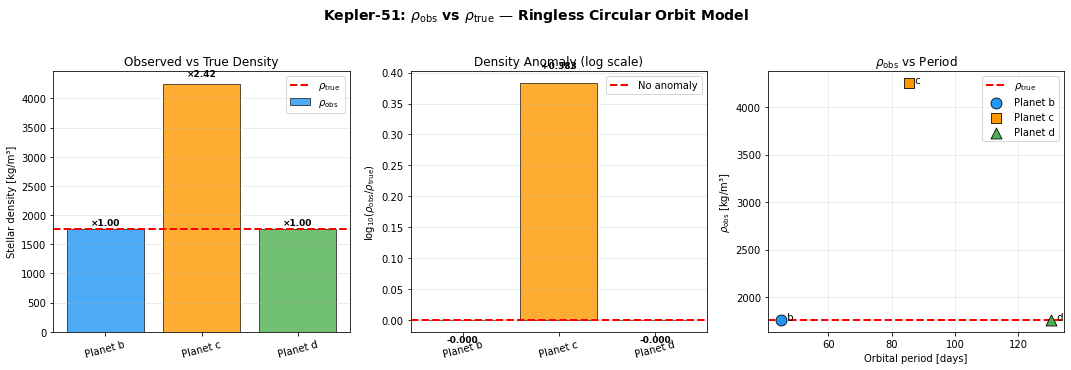

Figure saved to ../results/


In [51]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Kepler-51: $\\rho_{\\rm obs}$ vs $\\rho_{\\rm true}$ — Ringless Circular Orbit Model',
             fontsize=14, fontweight='bold', y=1.02)

colors = {'b': '#2196F3', 'c': '#FF9800', 'd': '#4CAF50'}
markers = {'b': 'o', 'c': 's', 'd': '^'}

# ── Panel 1: rho_obs vs rho_true (bar chart) ──────────────────────────────
ax1 = axes[0]
rho_true_val = star['rho_true']
labels  = df_results['name'].tolist()
rho_obs_vals = df_results['rho_obs'].tolist()
xs = np.arange(len(labels))

bar_colors = [colors[l] for l in df_results['label']]
bars = ax1.bar(xs, rho_obs_vals, color=bar_colors, alpha=0.8, edgecolor='k', linewidth=0.8,
               label='$\\rho_{\\rm obs}$')
ax1.axhline(rho_true_val, color='red', linewidth=2.0, linestyle='--', label='$\\rho_{\\rm true}$')

ax1.set_xticks(xs)
ax1.set_xticklabels([f'Planet {l}' for l in df_results['label']], rotation=15)
ax1.set_ylabel('Stellar density [kg/m³]')
ax1.set_title('Observed vs True Density')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Annotate ratio
for i, (x, rho_obs, ratio) in enumerate(zip(xs, rho_obs_vals,
                                              df_results['ratio'].tolist())):
    ax1.text(x, max(rho_obs, rho_true_val)*1.02,
             f'×{ratio:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Panel 2: log10(rho_obs/rho_true) per planet ───────────────────────────
ax2 = axes[1]
log_ratios = df_results['log_ratio'].tolist()
bar2 = ax2.bar(xs, log_ratios, color=bar_colors, alpha=0.8, edgecolor='k', linewidth=0.8)
ax2.axhline(0, color='red', linewidth=2.0, linestyle='--', label='No anomaly')
ax2.set_xticks(xs)
ax2.set_xticklabels([f'Planet {l}' for l in df_results['label']], rotation=15)
ax2.set_ylabel('$\\log_{10}(\\rho_{\\rm obs}/\\rho_{\\rm true})$')
ax2.set_title('Density Anomaly (log scale)')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
for i, (x, lr) in enumerate(zip(xs, log_ratios)):
    ax2.text(x, lr + (0.02 if lr >= 0 else -0.04),
             f'{lr:+.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Panel 3: rho_obs vs Orbital Period ────────────────────────────────────
ax3 = axes[2]
periods = df_results['P_days'].tolist()
for i, row in df_results.iterrows():
    ax3.scatter(row['P_days'], row['rho_obs'],
                color=colors[row['label']], marker=markers[row['label']],
                s=120, edgecolors='k', linewidth=0.8, zorder=5,
                label=f"Planet {row['label']}")
    ax3.annotate(f"  {row['name'].split()[-1]}",
                 (row['P_days'], row['rho_obs']), fontsize=10)

ax3.axhline(rho_true_val, color='red', linewidth=2.0, linestyle='--', label='$\\rho_{\\rm true}$')
ax3.set_xlabel('Orbital period [days]')
ax3.set_ylabel('$\\rho_{\\rm obs}$ [kg/m³]')
ax3.set_title('$\\rho_{\\rm obs}$ vs Period')
ax3.legend()
ax3.grid(alpha=0.3)

plt.tight_layout()
# plt.savefig('../results/kepler51_rho_obs_circular.pdf', bbox_inches='tight', dpi=150)
# plt.savefig('../results/kepler51_rho_obs_circular.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved to ../results/")

## 7. Transit Duration and Contact Times

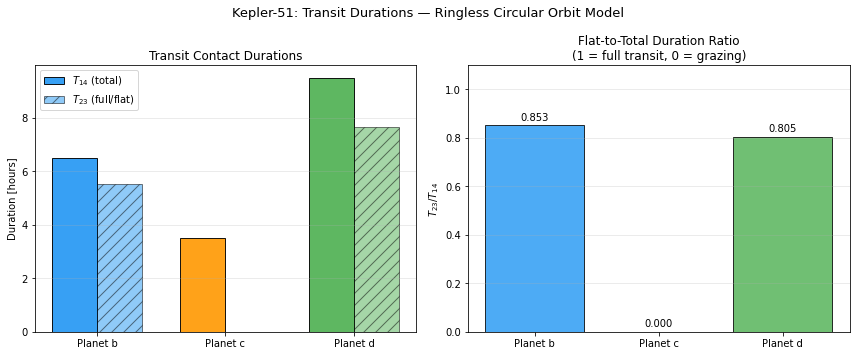

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Kepler-51: Transit Durations — Ringless Circular Orbit Model', fontsize=13)

# ── Panel 1: tT and tF ────────────────────────────────────────────────────
ax1 = axes[0]
xs  = np.arange(len(df_results))
w   = 0.35
ax1.bar(xs - w/2, df_results['tT_hours'], width=w, label='$T_{14}$ (total)',
        color=['%s' % colors[l] for l in df_results['label']], alpha=0.9, edgecolor='k')
ax1.bar(xs + w/2, df_results['tF_hours'], width=w, label='$T_{23}$ (full/flat)',
        color=['%s' % colors[l] for l in df_results['label']], alpha=0.5,
        edgecolor='k', hatch='//')
ax1.set_xticks(xs)
ax1.set_xticklabels([f'Planet {l}' for l in df_results['label']])
ax1.set_ylabel('Duration [hours]')
ax1.set_title('Transit Contact Durations')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: tF/tT ratio (shape indicator) ────────────────────────────────
ax2 = axes[1]
ratio_tFtT = df_results['tF_hours'] / df_results['tT_hours']
colors_list = [colors[l] for l in df_results['label']]
ax2.bar(xs, ratio_tFtT, color=colors_list, alpha=0.8, edgecolor='k')
ax2.set_xticks(xs)
ax2.set_xticklabels([f'Planet {l}' for l in df_results['label']])
ax2.set_ylabel('$T_{23}/T_{14}$')
ax2.set_title('Flat-to-Total Duration Ratio\n(1 = full transit, 0 = grazing)')
ax2.set_ylim(0, 1.1)
ax2.grid(axis='y', alpha=0.3)
for i, (x, r) in enumerate(zip(xs, ratio_tFtT)):
    ax2.text(x, r + 0.02, f'{r:.3f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 8. Physical Interpretation

The quantity $\rho_{\rm obs}$ is derived from the transit shape under the assumption of a **circular orbit** and a **bare (ringless) spherical planet**. Deviations from $\rho_{\rm true}$ — a directly measurable stellar property — reveal model inconsistencies.

### The Seager–Mallén-Ornelas formula

$$\rho_{\rm obs} = \frac{3\pi}{G P^2} \left(\frac{a}{R_\star}\right)^3$$

where $a/R_\star$ is inferred from the transit durations $T_{14}$ (total) and $T_{23}$ (full):

$$\frac{a}{R_\star} = \frac{2 \cdot \delta^{1/4}}{\sqrt{T_{14}^2 - T_{23}^2}} \cdot \frac{P}{\pi}$$

with $\delta = (R_p/R_\star)^2$. Any **additional opacity area** (rings) or **velocity modulation** (eccentricity) changes the inferred $a/R_\star$, and hence the inferred density.

### Connection to the Photo-Ring effect (Zuluaga et al.)

A **ringed planet** mimics a larger bare planet and modifies both $\delta$ and the duration ratios, leading to a systematic underestimate of $\rho_{\rm obs}$:

$$\delta_{\rm obs} = \frac{A_{\rm planet+ring}}{\pi R_\star^2} > \left(\frac{R_p}{R_\star}\right)^2$$

This shifts $\rho_{\rm obs} < \rho_{\rm true}$ (the "photo-ring" signature).

In [53]:
print("\n" + "="*60)
print("SUMMARY: rho_obs anomaly for Kepler-51 (circular, ringless)")
print("="*60)
print(f"  rho_true (star) = {star['rho_true']:.4f} kg/m^3")
print()
for _, row in df_results.iterrows():
    flag = ''
    if abs(row['log_ratio']) > 0.1:
        flag = ' *** SIGNIFICANT ANOMALY ***'
    if row['grazing']:
        flag += ' [grazing]'
    print(f"  Planet {row['label']:2s}: rho_obs = {row['rho_obs']:.4f} kg/m^3 "
          f" | rho_obs/rho_true = {row['ratio']:.4f}"
          f" | log10(ratio) = {row['log_ratio']:+.4f}{flag}")

print()
print("Interpretation:")
print("  - log10 > 0 => rho_obs > rho_true  (planet appears denser than star supports)")
print("  - log10 < 0 => rho_obs < rho_true  (potential photo-ring or eccentricity signal)")
print("  - |log10| ~ 0 => consistent with no anomaly (circular, bare planet)")


SUMMARY: rho_obs anomaly for Kepler-51 (circular, ringless)
  rho_true (star) = 1760.4752 kg/m^3

  Planet b : rho_obs = 1760.0032 kg/m^3  | rho_obs/rho_true = 0.9997 | log10(ratio) = -0.0001
  Planet c : rho_obs = 4253.4934 kg/m^3  | rho_obs/rho_true = 2.4161 | log10(ratio) = +0.3831 *** SIGNIFICANT ANOMALY *** [grazing]
  Planet d : rho_obs = 1760.3959 kg/m^3  | rho_obs/rho_true = 1.0000 | log10(ratio) = -0.0000

Interpretation:
  - log10 > 0 => rho_obs > rho_true  (planet appears denser than star supports)
  - log10 < 0 => rho_obs < rho_true  (potential photo-ring or eccentricity signal)
  - |log10| ~ 0 => consistent with no anomaly (circular, bare planet)


## 9. Sensitivity: Effect of Impact Parameter on $\rho_{\rm obs}$

Since $b$ is derived from fits that assume a bare spherical planet, we explore how $\rho_{\rm obs}$ varies as a function of $b$ around the archive value, keeping all other parameters fixed.

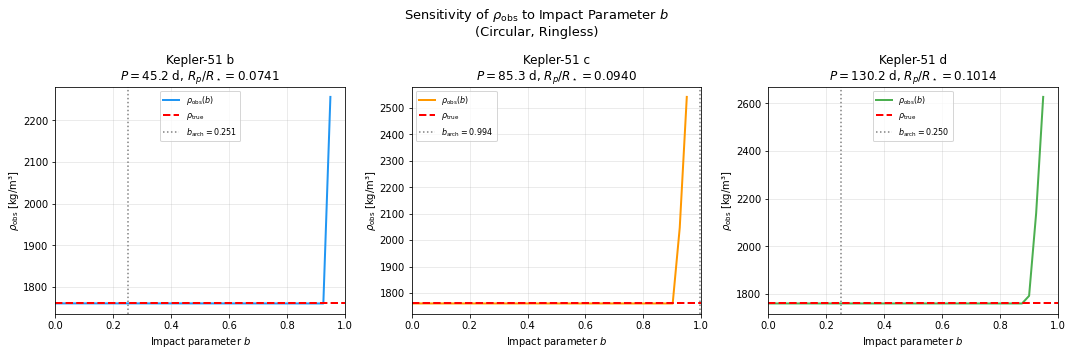

Figure saved to ../results/


In [54]:
fig, axes = plt.subplots(1, len(planets_data), figsize=(15, 5), sharey=False)
fig.suptitle('Sensitivity of $\\rho_{\\rm obs}$ to Impact Parameter $b$\n(Circular, Ringless)', fontsize=13)

b_grid = np.linspace(0.0, 0.95, 40)

for ax, planet, col_key in zip(axes, planets_data, ['b', 'c', 'd']):
    rho_obs_b = []
    for b_test in b_grid:
        planet_copy = dict(planet)
        planet_copy['b_imp'] = b_test
        try:
            S_test, _ = build_ringless_system(planet_copy, star)
            r = S_test.calculate_rho_obs()
            rho_obs_b.append(r)
        except Exception:
            rho_obs_b.append(np.nan)
    
    rho_obs_b = np.array(rho_obs_b)
    ax.plot(b_grid, rho_obs_b, '-', color=colors[col_key], lw=2, label='$\\rho_{\\rm obs}(b)$')
    ax.axhline(star['rho_true'], color='red', lw=2, ls='--', label='$\\rho_{\\rm true}$')
    ax.axvline(planet['b_imp'], color='gray', lw=1.5, ls=':', label=f"$b_{{\\rm arch}}={planet['b_imp']:.3f}$")
    ax.set_xlabel('Impact parameter $b$')
    ax.set_ylabel('$\\rho_{\\rm obs}$ [kg/m³]', labelpad=2)
    ax.set_title(f"{planet['name']}\n$P={planet['P_days']:.1f}$ d, $R_p/R_\\star={planet['Rp_Rstar']:.4f}$")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 1.0)

plt.tight_layout()
# plt.savefig('../results/kepler51_rho_obs_vs_b.pdf', bbox_inches='tight', dpi=150)
# plt.savefig('../results/kepler51_rho_obs_vs_b.png', bbox_inches='tight', dpi=150)
plt.show()
print("Figure saved to ../results/")

## 10. Comparison: Seager vs Kipping Formulas for $\rho_{\rm obs}$

GeoTrans uses the Seager & Mallén-Ornelas (2003) approximation. Here we compare with the exact Kipping (2014) formula.

In [55]:
print("Comparison: Seager (2003) vs Kipping (2014) rho_obs")
print("-"*65)
print(f"{'Planet':12s} {'rho_obs Seager':>18s} {'rho_obs Kipping':>18s} {'Diff %':>10s}")
print("-"*65)

for _, row in df_results.iterrows():
    p_sq   = row['Rp_Rstar']**2          # transit depth = (Rp/Rs)^2
    tT     = row['tT_hours']
    tF     = row['tF_hours']
    P_hrs  = row['P_days'] * 24.0
    
    rho_seager  = gt.rhoObserved_Seager(p_sq, star['Rstar'], tT, tF, P_hrs)
    rho_kipping = gt.rhoObserved_Kipping(p_sq, star['Rstar'], tT, tF, P_hrs)
    diff_pct = (rho_kipping - rho_seager) / rho_seager * 100
    
    print(f"{row['name']:12s} {rho_seager:18.4f} {rho_kipping:18.4f} {diff_pct:10.2f}%")

print("-"*65)
print(f"{'rho_true':12s} {star['rho_true']:18.4f}")

Comparison: Seager (2003) vs Kipping (2014) rho_obs
-----------------------------------------------------------------
Planet           rho_obs Seager    rho_obs Kipping     Diff %
-----------------------------------------------------------------
Kepler-51 b           1589.6237          1590.1581       0.03%
Kepler-51 c           3835.0521          3835.4720       0.01%
Kepler-51 d           1587.8242          1587.9549       0.01%
-----------------------------------------------------------------
rho_true              1760.4752


## 11. Conclusions

The table above summarises the key finding:

| Indicator | Meaning |
|-----------|----------|
| $\rho_{\rm obs}/\rho_{\rm true} \approx 1$ | Consistent with circular bare planet |
| $\rho_{\rm obs}/\rho_{\rm true} < 1$ | Transit appears slower/deeper than expected — ring, eccentricity, or blend |
| $\rho_{\rm obs}/\rho_{\rm true} > 1$ | Transit appears faster/shallower — could be high impact parameter or eccentricity |

**Next steps:**
- Introduce **eccentric orbits** for each planet (archive values: $e_b=0.04$, $e_c=0.014$, $e_d=0.008$) and re-compute $\rho_{\rm obs}$.
- Add **rings** ($f_e > 1$, $\tau > 0$) to all three planets and explore the parameter space.
- Fit the **actual Kepler light curves** and extract empirical $\rho_{\rm obs}$ from the data.
- Compare with the **photo-ring anomaly map** (PR = log$_{10}(\rho_{\rm obs}/\rho_{\rm true})$ as a function of ring inclination and external radius).